# Clustering

This notebook applies K-Means clustering to identify groups of similar pitch trajectories.


In [8]:
import pandas as pd
from pathlib import Path

DATA_RAW = Path("../data/raw").resolve()

csv_file = next(DATA_RAW.glob("*.csv"))

df = pd.read_csv(csv_file)

X = df.iloc[:, 1:]

print(X.shape)

(3000, 365)


In [9]:
X_filled = X.fillna(X.mean())

print("Missing values before:", X.isnull().sum().sum())
print("Missing values after :", X_filled.isnull().sum().sum())

Missing values before: 20293
Missing values after : 0


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_filled)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (3000, 365)


In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("Clusters:", set(cluster_labels))

Clusters: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}


In [12]:
import pandas as pd

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

print(cluster_counts)

0     609
1     925
2     203
3    1263
Name: count, dtype: int64


In [13]:
DATA_PROCESSED = Path("../data/processed").resolve()
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

cluster_df = pd.DataFrame({
    "ID": df["ID"],
    "Cluster": cluster_labels
})

output_file = DATA_PROCESSED / "cluster_results.csv"

cluster_df.to_csv(output_file, index=False)

print("Saved to:", output_file)

Saved to: C:\Users\tualtan\Projects\SymbTr-Analysis-Book\webbook\data\processed\cluster_results.csv


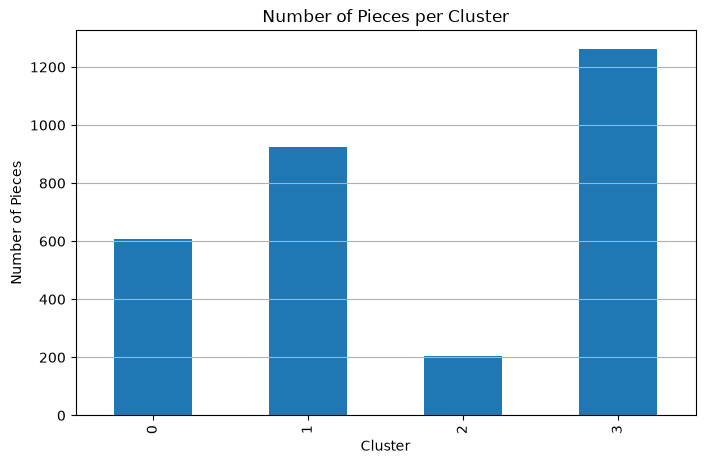

In [14]:
import matplotlib.pyplot as plt

cluster_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Pieces per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Pieces")

plt.grid(axis="y")
plt.show()